In [1]:
figure_utils_dir <- if (dir.exists("utils")) "utils" else file.path("code", "figures", "utils")
source(file.path(figure_utils_dir, "common_setup.R"))
source(file.path(figure_utils_dir, "plot_helpers.R"))
source(file.path(figure_utils_dir, "module_helpers.R"))
load_figure_libraries(c("ggtree", "paletteer", "readxl", "limma", "tidytext"))

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘sp’ was built under R version 4.4.2”
Warning message:
“package ‘qs’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘patchwork’ was built under R version 4.4.3”
Warning message:
“package ‘latex2exp’ was built under R version 4.4.3”
Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.4.2”
Warning message:
“package ‘AnnotationDbi’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘Biobase’ was built under R version 4.4.2”
Warning message:
“package ‘IRanges’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘clusterProfiler’ was built under R version 4.4.2”
Warning 

# 5C

In [2]:
all_sample_ids <- get_all_sample_ids()
height_width_param <- get_height_width_param()
all_xenium_merged <- load_merged_xenium_samples(sample_ids = all_sample_ids)

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Normalizing layer: counts



In [3]:
all_module_wgcna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/Merged_WGCNA_gene_kME.csv")

In [4]:
module_list_Ian_spatial_wgcna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/spatialmodules101625.csv")
module_list_Ian_spatial_wgcna %>% filter(Gene %in% rownames(all_xenium_merged)) -> module_list_Ian_spatial_wgcna 
module_list_Ian_spatial_wgcna <- split(module_list_Ian_spatial_wgcna, module_list_Ian_spatial_wgcna$Title)
module_list_Ian_spatial_wgcna <- lapply(module_list_Ian_spatial_wgcna, function(module_df){
    setNames(module_df$Weight, module_df$Gene)
})

In [6]:
module_scores_wgcna_2 <- getWeightedModuleScore(names(module_list_Ian_spatial_wgcna[["ME1_pkME"]]),
                           unname(module_list_Ian_spatial_wgcna[["ME1_pkME"]]),
                           all_xenium_merged,
                           "ME1_pkME",
                           assay="Xenium",
                           ctrl_size=20)

In [7]:
plt_data_module <- cbind(all_xenium_merged@meta.data, module_scores_wgcna_2[rownames(all_xenium_merged@meta.data), , drop=FALSE])

In [8]:
shared_scale <- getSharedScales(plt_data_module[["ME1_pkME"]], 0)
all_module_plt_5c <- lapply(all_sample_ids, function(sample_id){
    figure_height_width <- get_sample_dimensions(sample_id, height_width_param)
    spatialValuePlot(plt_data_module %>% filter(sample==sample_id),
                     custom_scale=TRUE,
                     scale_externel=shared_scale,
                     pt.size=0.2,
                     stroke=0,
                     variable="ME1_pkME",
                     x_column="y",
                     y_column="x",
                     order=TRUE,
                     legend_title="ME1_pKME") -> plt.tmp
    ggsave(plot=plt.tmp,
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5C_{sample_id}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2],
           dpi=700,
           limitsize=FALSE
           )
})


# 5B

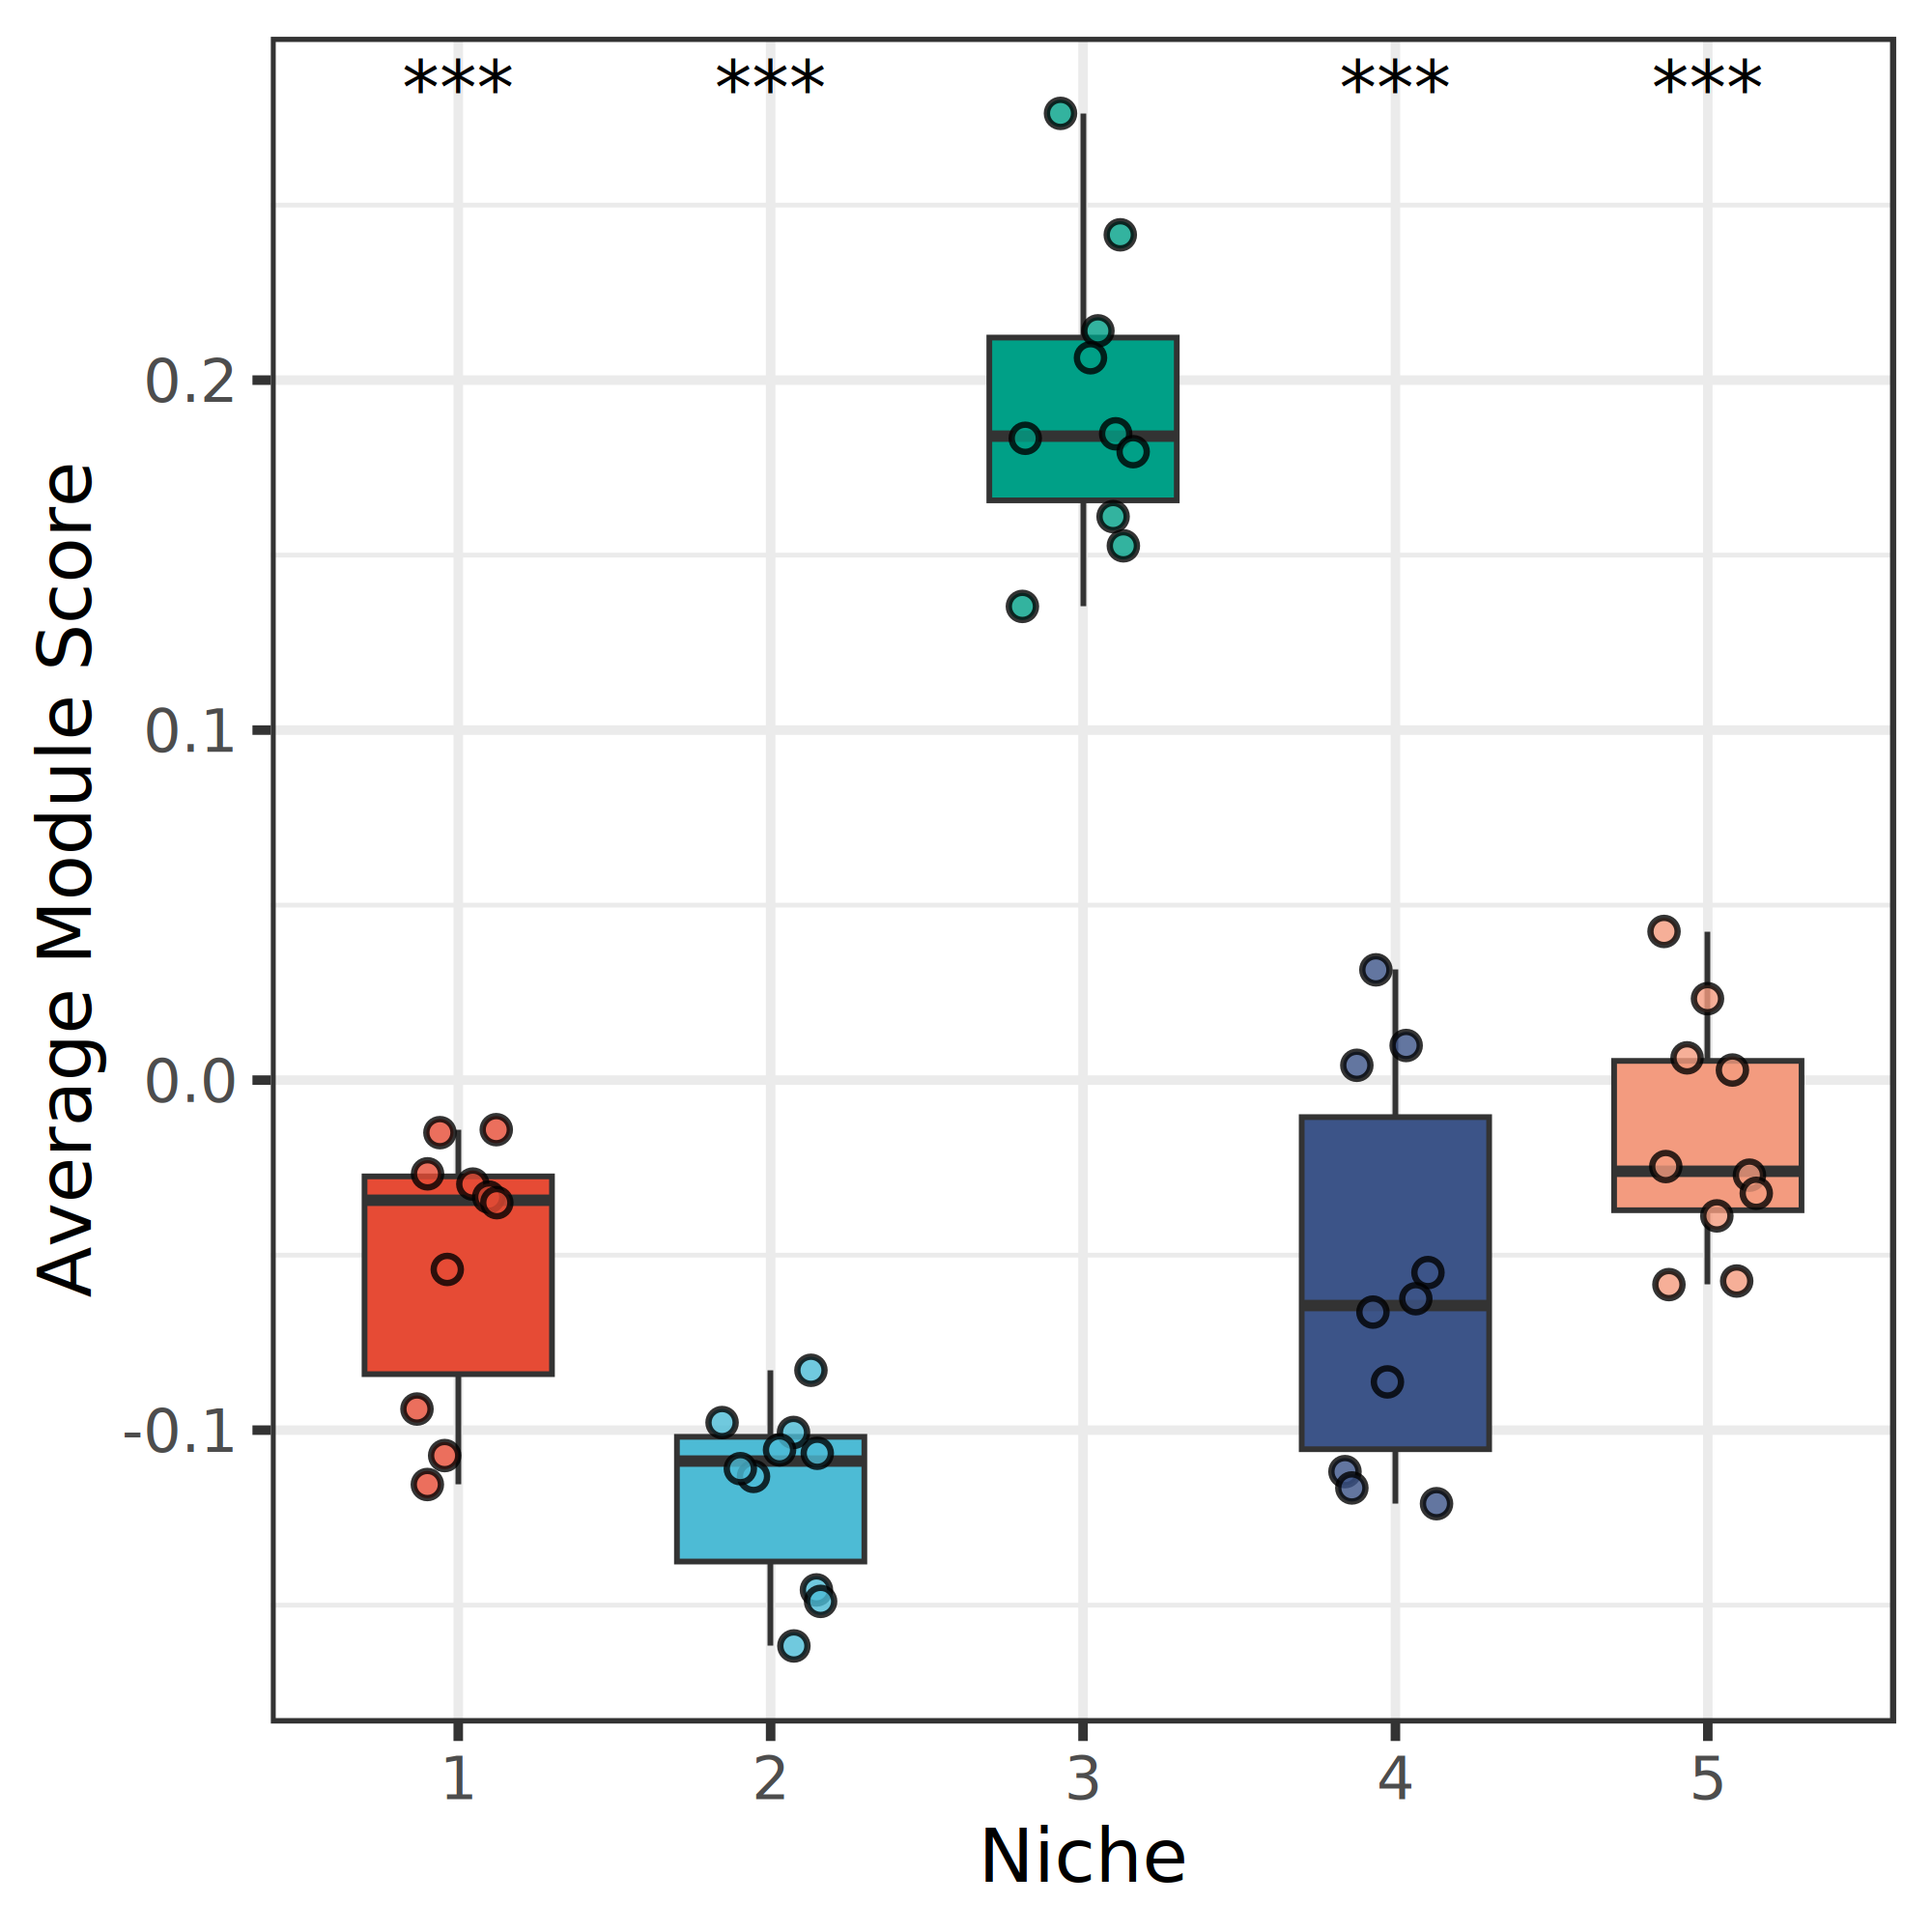

In [10]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 500)
niche_palette <- pal_npg()(5)
names(niche_palette) <- as.character(seq(1, 5))
plt_data_module %>%
  select(ME1_pkME, sample, Niche) %>%
  group_by(Niche, sample) %>%
  summarize(mean_score = mean(ME1_pkME, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = Niche, y = mean_score)) +
  geom_boxplot(aes(fill = Niche),
               width = 0.6, outlier.shape = NA, linewidth = 0.3) +
  geom_point(aes(fill = Niche),
             colour="black",
             shape=21,
             position = position_jitter(width = 0.2, height = 0),
             size = 1.5, alpha = 0.8) +
  scale_fill_manual(values = niche_palette) + 
  stat_compare_means(
    ref.group = "3",
    paired = TRUE,
    label = "p.signif",
    method = "wilcox.test",
    method.args = list(alternative = "less")
  ) +
  theme_bw() +
  theme(legend.position="none") +
  labs(y="Average Module Score")
ggsave(filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5B.png"),
       height=4,
       width=4,
       dpi=700
       )

# 5D

In [12]:
tcz_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/TCZ_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
rtx_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/RTX_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
merged_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/Merged_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
patient_info <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/R4RA_phenotype.csv")

In [13]:
patient_info %>%
    mutate(treatment=ifelse(Timepoint==0, "C", "T"),
           treatment=factor(treatment, levels=c("C", "T"))) -> patient_info

In [14]:
patient_info %>%
    filter(Drug=="TOC" & Timepoint==0 & Pathotype=="Myeloid") %>%
    pull(Patient_ID) -> tcz_meyloid_0_sample_ids

In [15]:
patient_info %>%
    filter(Patient_ID %in% tcz_meyloid_0_sample_ids, Header %in% colnames(tcz_rna)) %>%
    group_by(Patient_ID) %>%
    mutate(n_sample=n()) %>%
    ungroup() %>%
    filter(n_sample==2) %>%
    tibble::column_to_rownames("Header") %>%
    mutate(patient_id=factor(Patient_ID)) -> tcz_patient_info_myeloid
design_tcz_16_v_0_myeloid <- model.matrix(~treatment + patient_id, data=tcz_patient_info_myeloid)
tcz_16_v_0_rna_myeloid <- tcz_rna[, rownames(design_tcz_16_v_0_myeloid)]

In [16]:
fit_tcz_16_v_0_rna_myeloid <- lmFit(tcz_16_v_0_rna_myeloid, design=design_tcz_16_v_0_myeloid)
fit_tcz_16_v_0_rna_myeloid <- eBayes(fit_tcz_16_v_0_rna_myeloid, trend=TRUE)
topTable(fit_tcz_16_v_0_rna_myeloid, coef = "treatmentT", number = Inf, adjust.method = "BH") %>%
    arrange(logFC) -> DEGs_all_tcz_16_v_0_meyloid

In [17]:
sc_ref <- qread("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/AMP_PhaseII_seurat.qs")
metadata_all_sc_ref <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/all_cells_reference.rds")

In [18]:
module_tcz_16_v_0_meyloid <- organizeDEGsList(-0.5,
                                      0.01,
                                      DEGs_all_tcz_16_v_0_meyloid,
                                      sc_ref)

In [19]:
tcz_16_v_0_myeloid_module_scores <- getWeightedModuleScorescRNA(names(module_tcz_16_v_0_meyloid),
                           unname(module_tcz_16_v_0_meyloid),
                           sc_ref,
                           "TCZ_Myeloid_w16_v_w0")

In [20]:
umap_embeddings <- data.frame(metadata_all_sc_ref$umap$embedding)
rownames(umap_embeddings) <- metadata_all_sc_ref$meta_data$cell
umap_embeddings <- cbind(umap_embeddings, tcz_16_v_0_myeloid_module_scores[rownames(umap_embeddings), ,drop=FALSE])
umap_embeddings$ct <- sc_ref@meta.data[rownames(umap_embeddings), ]$cluster_name
umap_embeddings$broad_ct <- sc_ref@meta.data[rownames(umap_embeddings), ]$cell_type
umap_embeddings %>%
  mutate(ct=gsub(":.+", "", as.character(ct)),
         ct=gsub(" .+", "", ct)) -> umap_embeddings

In [21]:
mac_superset_cluster_pal <- brewer.pal("Set3", n=5)
mac_superset_cluster_pal <- mac_superset_cluster_pal[-2]
names(mac_superset_cluster_pal) <- c("DC", "Monocytes", "SPP1hi", "Tissue")

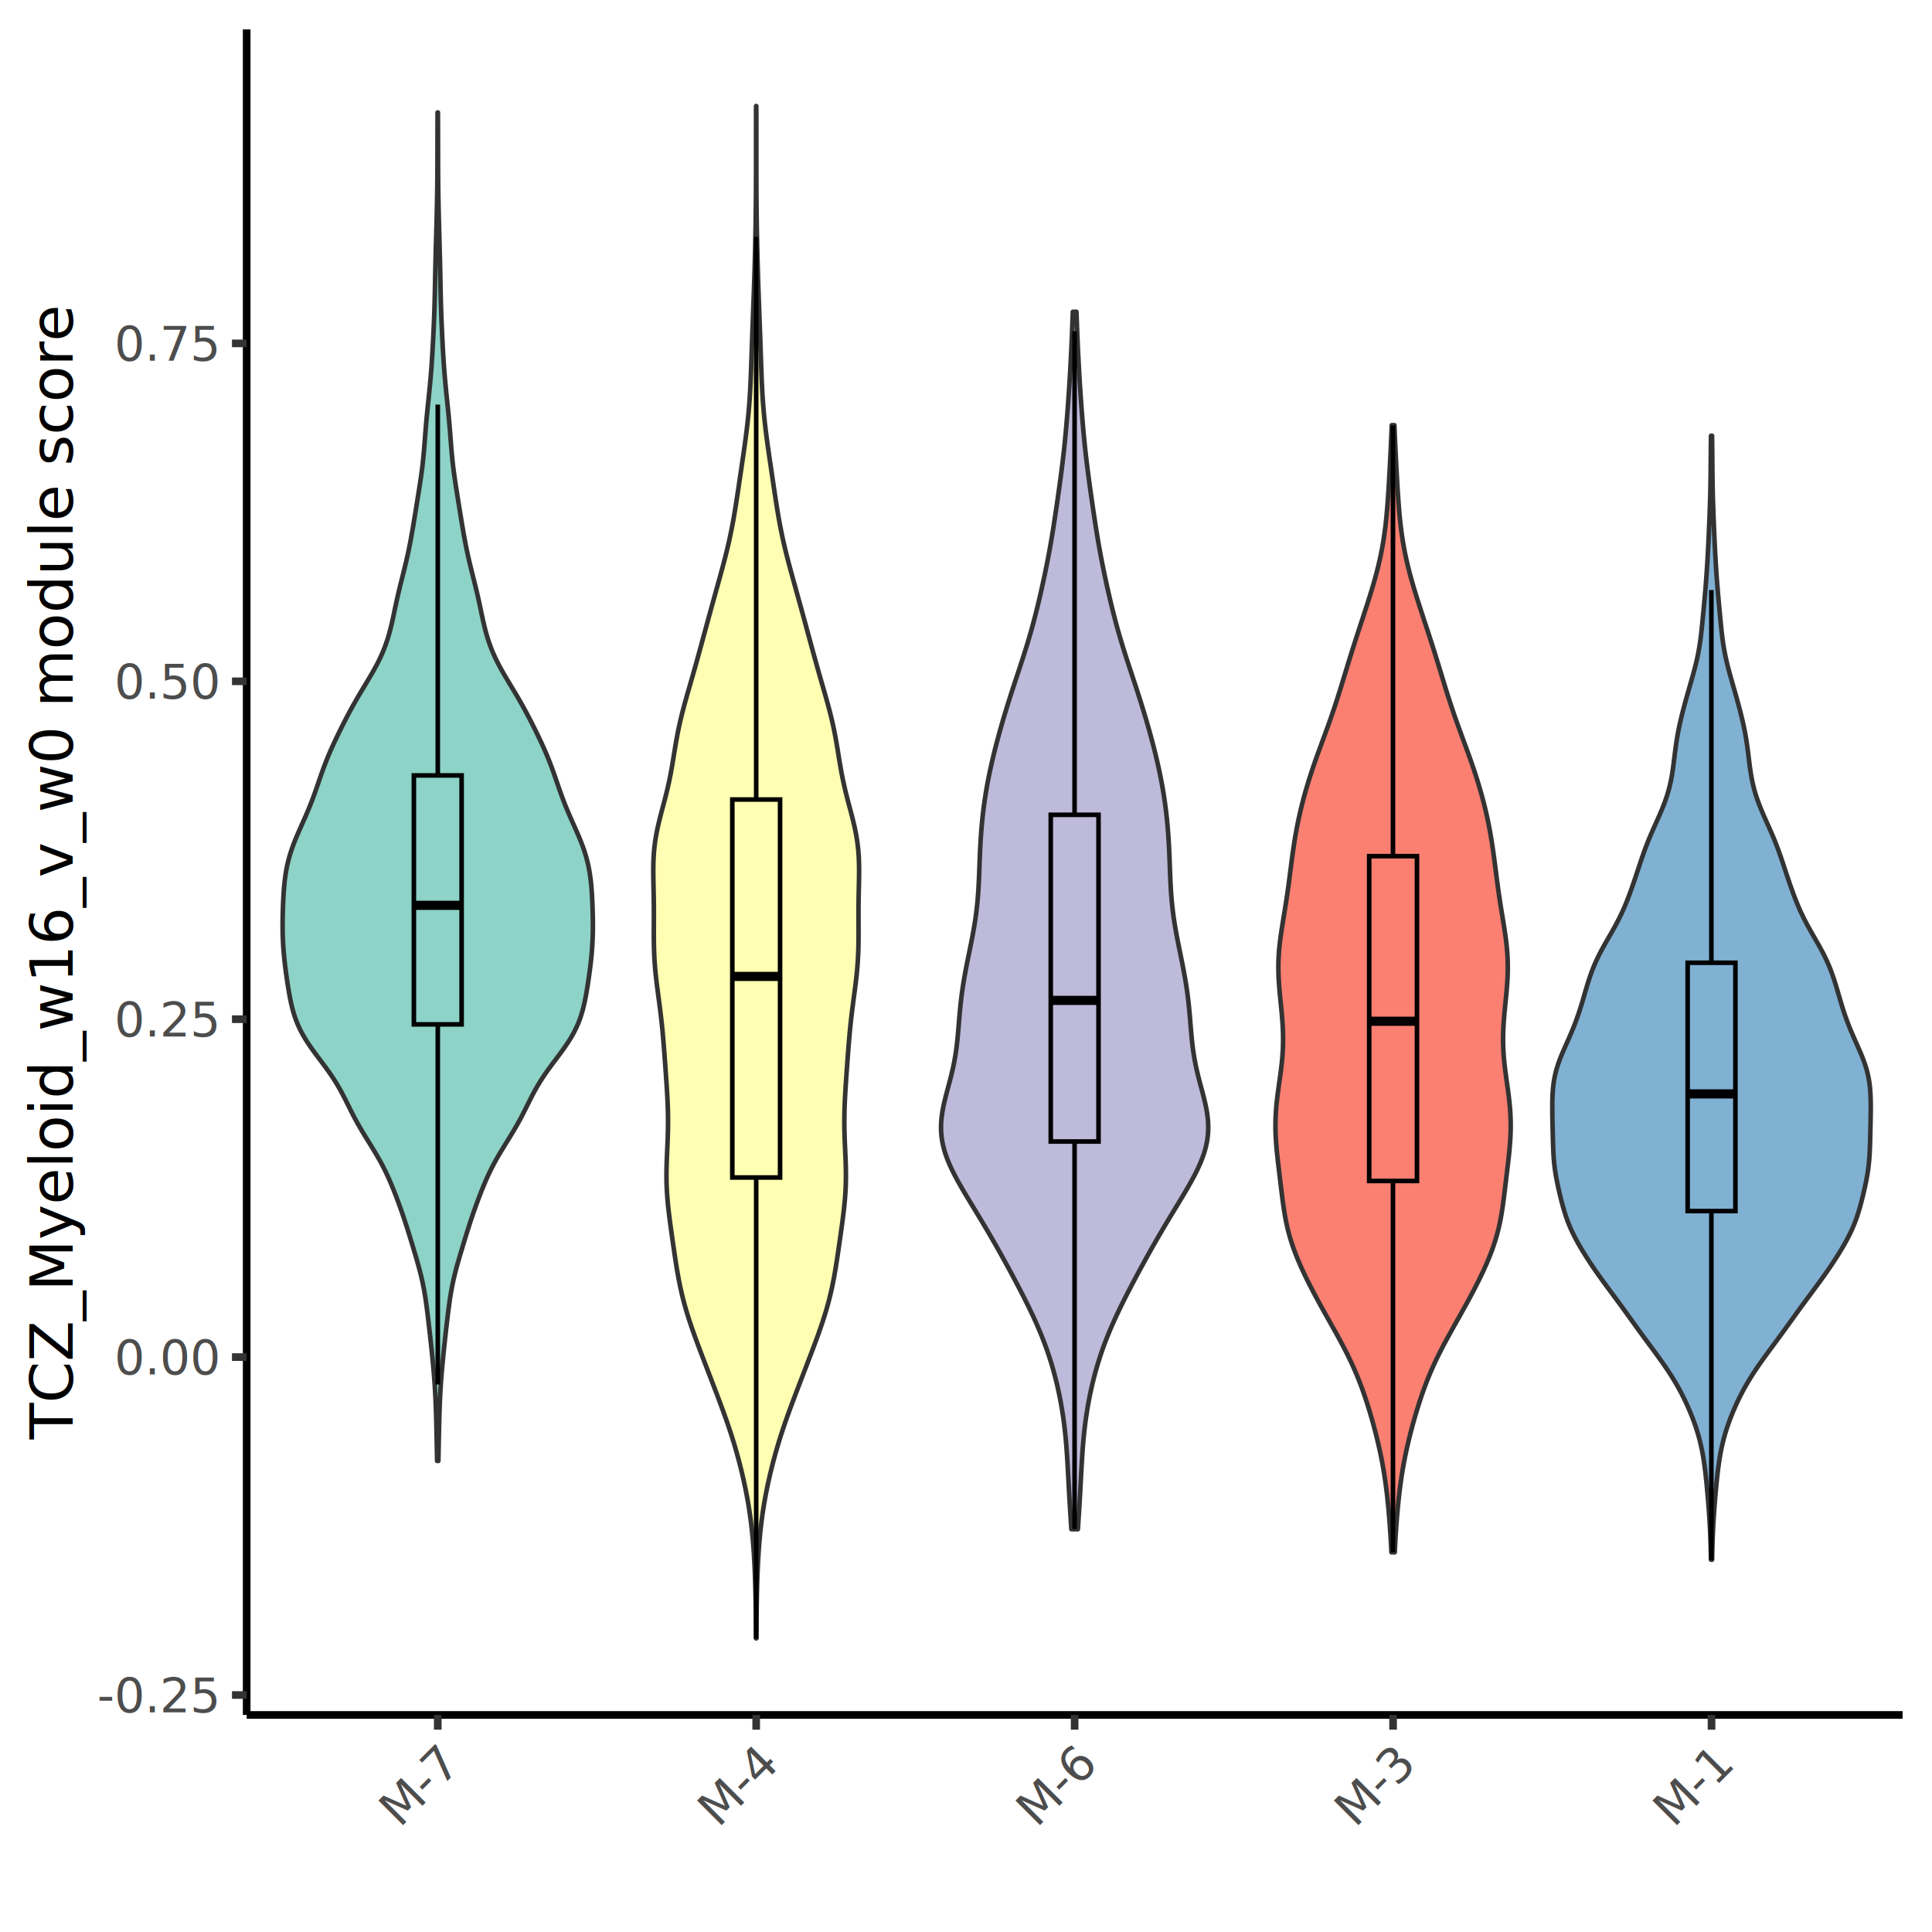

In [22]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 500)
umap_embeddings %>%
        mutate(ct = reorder(ct,TCZ_Myeloid_w16_v_w0, FUN = median, decreasing = TRUE)) -> plt.df.module.myeloid.tcz
top_cts <- levels(plt.df.module.myeloid.tcz$ct)[1:5]
plt.df.module.myeloid.tcz[["TCZ_Myeloid_w16_v_w0"]] <- plt.df.module.myeloid.tcz[["TCZ_Myeloid_w16_v_w0"]] + rnorm(mean=0, sd=1e-8, n=nrow(plt.df.module.myeloid.tcz))
ggplot(plt.df.module.myeloid.tcz %>% filter(ct %in% top_cts), aes(x = ct, y = TCZ_Myeloid_w16_v_w0, fill=ct)) +
    geom_violin(trim = TRUE, width=1, linewidth=0.3) +
    geom_boxplot(width = 0.15, color = "black", outliers=FALSE, linewidth=0.3) +
    theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
    xlab("") +
    ylab("TCZ_Myeloid_w16_v_w0 module score") +
    scale_fill_manual(values=brewer.pal("Set3", n=5))
ggsave(filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5D.png"),
       height=5,
       width=5,
       dpi=700
       )